In [10]:
import pandas as pd

experiments = {
    "FCN32 Baseline": "metrics_FCN32_1-exit.csv",
    "FCN32 Aux s32 λ=0.4": "metrics_FCN32_2-exit_s-32-0.4.csv",

    "FCN16 Baseline": "metrics_FCN16_1-exit.csv",
    "FCN16 Aux s32 λ=0.4": "metrics_FCN16_2-exit_s-32-0.4.csv",

    "FCN8 Baseline": "metrics_FCN8_1-exit.csv",

    "FCN8 Aux s32 λ=0.4": "metrics_FCN8_2-exit_s-32-0.4.csv",
    "FCN8 Aux s32 λ=0.1": "metrics_FCN8_2-exit_s-32-0.1.csv",

    "FCN8 Aux s16 λ=0.4": "metrics_FCN8_2-exit_s-16-0.4.csv",
    "FCN8 Aux s16 λ=0.2": "metrics_FCN8_2-exit_s-16-0.2.csv",
    "FCN8 Aux s16 λ=0.125": "metrics_FCN8_2-exit_s-16-0.125.csv",
    "FCN8 Aux s16 λ=0.1": "metrics_FCN8_2-exit_s-16-0.1.csv",
    "FCN8 Aux s16 λ=0.075": "metrics_FCN8_2-exit_s-16-0.075.csv",

    "FCN8 Aux s16+s32 λ=0.4":
        "metrics_FCN8_3-exit_s-16-0.4-s-32-0.4.csv",

    "FCN8 No skip Baseline":
        "metrics_FCN8_no-skip_1-exit.csv",

    "FCN8 No skip Aux s16 λ=0.1":
        "metrics_FCN8_no-skip_2-exit_s-16-0.1.csv",

    "FCN8 Upscale Aux s16 λ=0.1":
        "metrics_FCN8_upscale_2exit_s16-0.1.csv",
    
    "FCN8 Upscale Aux s32 λ=0.1":
        "metrics_FCN8_upscale_2exit_s-32-0.1.csv",

    "FCN8 Interp s16 λ=0.1":
        "metrics_FCN8_interpolate_2exit_s16-0.1.csv",
    
    "FCN16 No Skip Baseline":
        "metrics_FCN16_no-skip_1-exit.csv",
    
    "FCN16 No Skip Aux s32 λ=0.1":
        "metrics_FCN16_no-skip_2-exit_s-32-0.1.csv"
}

LAST_N = 20  # janela do platô: média das últimas N épocas (robusto a pico/spike)

results = []

for model_name, file in experiments.items():

    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    best_row = df.loc[df["miou"].idxmax()]

    results.append({
        "Model": model_name,
        "Epochs": len(df),                                              # <-- expõe runs truncadas
        "Best Epoch": int(best_row["epoch"]),
        "Best mIoU": round(float(best_row["miou"]), 4),
        f"mIoU last{LAST_N}": round(float(df["miou"].tail(LAST_N).mean()), 4),  # <-- platô
        "Pixel Acc": round(float(best_row["mean_pixel_acc"]), 4),
        "Train Loss": round(float(best_row["train_loss"]), 4),
        "Val Loss": round(float(best_row["val_loss"]), 4),
    })

summary_df = pd.DataFrame(results)
# ordena pelo platô (mais confiável que o pico único)
summary_df = summary_df.sort_values(by=f"mIoU last{LAST_N}", ascending=False)

print(summary_df.to_string(index=False))
print("\n⚠️  runs com Epochs << 200 nao convergiram -> nao comparar best/plateau com as longas")

summary_df.to_csv("summary_best_results.csv", index=False)

                      Model  Epochs  Best Epoch  Best mIoU  mIoU last20  Pixel Acc  Train Loss  Val Loss
         FCN8 Aux s16 λ=0.1     176          84     0.3632       0.3496     0.4573      0.1600    0.7366
              FCN8 Baseline     200         139     0.3594       0.3413     0.4614      0.1334    0.7556
             FCN16 Baseline     200          99     0.3616       0.3393     0.4663      0.1547    0.7469
       FCN8 Aux s16 λ=0.075     200         101     0.3593       0.3393     0.4503      0.1410    0.7179
       FCN8 Aux s16 λ=0.125      97          68     0.3599       0.3379     0.4776      0.1968    0.7366
      FCN8 Interp s16 λ=0.1     200         199     0.3559       0.3372     0.4473      0.0991    0.7321
         FCN8 Aux s16 λ=0.2     175          68     0.3470       0.3349     0.4479      0.2272    0.7442
         FCN8 Aux s16 λ=0.4     200         162     0.3585       0.3342     0.4674      0.1685    0.7321
 FCN8 Upscale Aux s32 λ=0.1     200         106     0.3

KeyError: 'FCN16 No Skip Baseline'

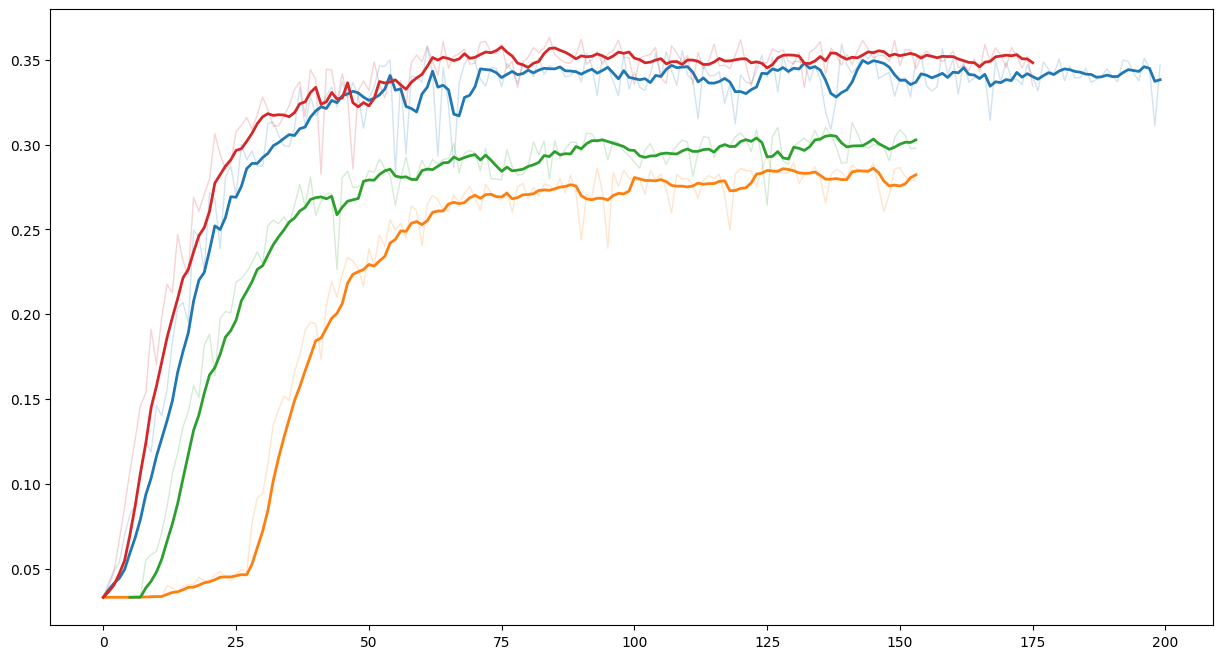

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

experiments = {
    "FCN32 Baseline":
        "metrics_FCN32_1-exit.csv",

    "FCN32 Aux s32 λ=0.4":
        "metrics_FCN32_2-exit_s-32-0.4.csv",

    "FCN16 Baseline":
        "metrics_FCN16_1-exit.csv",

    "FCN16 Aux s32 λ=0.4":
        "metrics_FCN16_2-exit_s-32-0.4.csv",

    "FCN8 Baseline":
        "metrics_FCN8_1-exit.csv",

    "FCN8 Aux s32 λ=0.4":
        "metrics_FCN8_2-exit_s-32-0.4.csv",

    "FCN8 Aux s32 λ=0.1":
        "metrics_FCN8_2-exit_s-32-0.1.csv",

    "FCN8 Aux s16 λ=0.4":
        "metrics_FCN8_2-exit_s-16-0.4.csv",

    "FCN8 Aux s16 λ=0.2":
        "metrics_FCN8_2-exit_s-16-0.2.csv",

    "FCN8 Aux s16 λ=0.125":
        "metrics_FCN8_2-exit_s-16-0.125.csv",

    "FCN8 Aux s16 λ=0.1":
        "metrics_FCN8_2-exit_s-16-0.1.csv",

    "FCN8 Aux s16 λ=0.075":
        "metrics_FCN8_2-exit_s-16-0.075.csv",

    "FCN8 Aux s16+s32 λ=0.4":
        "metrics_FCN8_3-exit_s-16-0.4-s-32-0.4.csv",

    "FCN8 No Skip Baseline":
        "metrics_FCN8_no-skip_1-exit.csv",

    "FCN8 No Skip Aux s16 λ=0.1":
        "metrics_FCN8_no-skip_2-exit_s-16-0.1.csv",

    "FCN8 Upscale Aux s16 λ=0.1":
        "metrics_FCN8_upscale_2exit_s16-0.1.csv",

    "FCN8 Upscale Aux s32 λ=0.1":
        "metrics_FCN8_upscale_2exit_s32-0.1.csv",

    "FCN8 Interp s16 λ=0.1":
        "metrics_FCN8_interpolate_2exit_s16-0.1.csv",
    
    "FCN16 No Skip Baseline":
        "metrics_FCN16_no-skip_1-exit.csv",
    
    "FCN16 No Skip Aux s32 λ=0.1":
        "metrics_FCN16_no-skip_2-exit_s-32-0.1.csv"

}

# ==========================================
# Escolha aqui o que quer plotar
# ==========================================

enabled1 = [
    "FCN32 Baseline",
    "FCN32 Aux s32 λ=0.4",
    "FCN16 Baseline",
    "FCN16 Aux s32 λ=0.4",
    "FCN8 Baseline",
    "FCN8 Aux s32 λ=0.4",
    "FCN8 Aux s32 λ=0.1",
    "FCN8 Aux s16 λ=0.4",
    "FCN8 Aux s16 λ=0.2",
    "FCN8 Aux s16 λ=0.125",
    "FCN8 Aux s16 λ=0.1",
    "FCN8 Aux s16 λ=0.075",
    "FCN8 Aux s16+s32 λ=0.4",
    "FCN8 No Skip Baseline",
    "FCN8 No Skip Aux s16 λ=0.1",
    "FCN8 Upscale Aux s16 λ=0.1",
    "FCN8 Upscale Aux s32 λ=0.1"
]

enabled2 = [
    "FCN8 Baseline",
    "FCN8 Aux s16 λ=0.4",
    "FCN8 Aux s16 λ=0.2",
    "FCN8 Aux s16 λ=0.125",
    "FCN8 Aux s16 λ=0.1",
    "FCN8 Aux s16 λ=0.075",
]

enabled3 = [
    "FCN8 Baseline",
    "FCN8 No Skip Baseline",
    "FCN8 No Skip Aux s16 λ=0.1",
    "FCN8 Aux s16 λ=0.1",
    "FCN16 No Skip Baseline",
    "FCN16 No Skip Aux s32 λ=0.1"
    
]

enabled4 = [
    "FCN32 Baseline",
    "FCN16 Baseline",
    "FCN8 Baseline",
]

enabled5 = [
    "FCN8 Baseline",
    "FCN8 Aux s16 λ=0.1",
    "FCN8 Upscale Aux s16 λ=0.1",
    "FCN8 Upscale Aux s32 λ=0.1"
]

enabled6 = [
    "FCN32 Baseline",
    "FCN32 Aux s32 λ=0.4",
]

# A/B do s16: downsample vs interp vs deconv vs baseline
enabled7 = [
    "FCN8 Baseline",
    "FCN8 Aux s16 λ=0.1",          # downsample da GT
    "FCN8 Interp s16 λ=0.1",       # upsample por interpolacao (sem params)
    "FCN8 Upscale Aux s16 λ=0.1",  # upsample por deconv (com params)
]

# ==========================================
# Seletor: troque o grupo e a suavizacao aqui
# ==========================================
group = enabled3          # enabled1..7
SMOOTH = 5                # janela de media movel das curvas (1 = sem suavizar)

plt.figure(figsize=(15, 8))

for name in group:
    df = pd.read_csv(experiments[name])
    df.columns = df.columns.str.strip()
    y = df["miou"].rolling(SMOOTH, min_periods=1).mean()
    line, = plt.plot(df["epoch"], y, linewidth=2, label=name)        # curva suavizada
    plt.plot(df["epoch"], df["miou"], linewidth=1, alpha=0.2,
             color=line.get_color())                                 # curva crua (faint, mesma cor)

plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.title(f"FCN Experiments (smooth={SMOOTH})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

experiments = {
    "FCN32 Baseline": "metrics_FCN32_1-exit.csv",
    "FCN32 Aux s32 λ=0.4": "metrics_FCN32_2-exit_s-32-0.4.csv",

    "FCN16 Baseline": "metrics_FCN16_1-exit.csv",
    "FCN16 Aux s32 λ=0.4": "metrics_FCN16_2-exit_s-32-0.4.csv",

    "FCN8 Baseline": "metrics_FCN8_1-exit.csv",
    "FCN8 Aux s32 λ=0.4": "metrics_FCN8_2-exit_s-32-0.4.csv",
    "FCN8 Aux s32 λ=0.1": "metrics_FCN8_2-exit_s-32-0.1.csv",

    "FCN8 Aux s16 λ=0.4": "metrics_FCN8_2-exit_s-16-0.4.csv",
    "FCN8 Aux s16 λ=0.2": "metrics_FCN8_2-exit_s-16-0.2.csv",
    "FCN8 Aux s16 λ=0.125": "metrics_FCN8_2-exit_s-16-0.125.csv",
    "FCN8 Aux s16 λ=0.1": "metrics_FCN8_2-exit_s-16-0.1.csv",
    "FCN8 Aux s16 λ=0.075": "metrics_FCN8_2-exit_s-16-0.075.csv",

    "FCN8 Aux s16+s32 λ=0.4":
        "metrics_FCN8_3-exit_s-16-0.4-s-32-0.4.csv",

    "FCN8 No Skip Baseline":
        "metrics_FCN8_no-skip_1-exit.csv",

    "FCN8 No Skip Aux s16 λ=0.1":
        "metrics_FCN8_no-skip_2-exit_s-16-0.1.csv",

    "FCN8 Upscale Aux s16 λ=0.1":
        "metrics_FCN8_upscale_2exit_s16-0.1.csv",
        
    "FCN8 Upscale Aux s32 λ=0.1":
        "metrics_FCN8_upscale_2exit_s32-0.1.csv",
    
    "FCN8 Upscale Interpolate s16 λ=0.1":
        "metrics_FCN8_interpolate_2exit_s16-0.1.csv",

    "FCN16 No Skip Baseline":
        "metrics_FCN16_no-skip_1-exit.csv",
    
    "FCN16 No Skip Aux s32 λ=0.1":
        "metrics_FCN16_no-skip_2-exit_s-32-0.1.csv"
}

LAST_N = 20
rows = []

for name, file in experiments.items():

    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    best = df.loc[df["miou"].idxmax()]

    rows.append({
        "Model": name,
        "Epochs": len(df),
        "Best@": int(best["epoch"]),
        "mIoU": round(float(best["miou"]), 4),
        f"mIoU_l{LAST_N}": round(float(df["miou"].tail(LAST_N).mean()), 4),
        "PixelAcc": round(float(best["mean_pixel_acc"]), 4),
        "ValLoss": round(float(best["val_loss"]), 4),
    })

summary = pd.DataFrame(rows)
# platô (média últimas N) é mais confiável que o pico p/ ranquear
summary = summary.sort_values(f"mIoU_l{LAST_N}", ascending=False)

print(summary.to_string(index=False))
print("\n⚠️  Epochs << 200 = nao convergiu (ex.: Upscale=42) -> comparar so entre duracoes parecidas")

FileNotFoundError: [Errno 2] No such file or directory: 'metrics_FCN8_upscale_2exit_s32-0.1.csv'

In [ ]:
import pandas as pd

for name, file in experiments.items():

    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    top5 = df.nlargest(5, "miou")

    print("\n" + "="*80)
    print(name)

    print(
        top5[
            ["epoch", "miou", "mean_pixel_acc"]
        ].to_string(index=False)
    )


FCN32 Baseline
 epoch   miou  mean_pixel_acc
    75 0.3115          0.4156
    68 0.3104          0.4007
    98 0.3103          0.4055
   133 0.3100          0.4124
   101 0.3084          0.4082

FCN32 Aux s32 λ=0.4
 epoch   miou  mean_pixel_acc
   114 0.3176          0.4217
    65 0.3173          0.4322
   145 0.3167          0.4109
    80 0.3158          0.4390
    57 0.3155          0.4412

FCN16 Baseline
 epoch   miou  mean_pixel_acc
    99 0.3616          0.4663
    89 0.3601          0.4748
    84 0.3562          0.4570
    98 0.3550          0.4782
    80 0.3536          0.4690

FCN16 Aux s32 λ=0.4
 epoch   miou  mean_pixel_acc
    71 0.3265          0.4214
   140 0.3241          0.4148
    69 0.3238          0.4133
    85 0.3238          0.4149
    90 0.3228          0.4169

FCN8 Baseline
 epoch   miou  mean_pixel_acc
   139 0.3594          0.4614
    61 0.3580          0.4765
   158 0.3565          0.4493
   109 0.3553          0.4522
   145 0.3552          0.4550

FCN8 Aux s

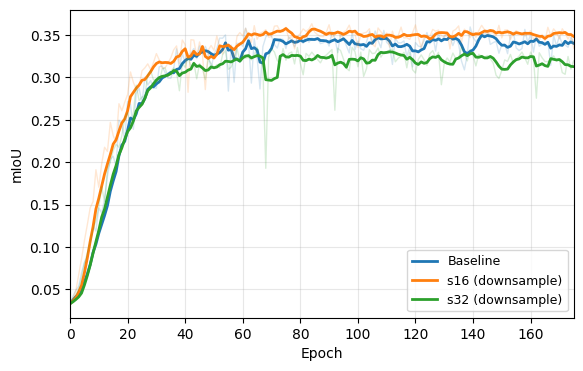

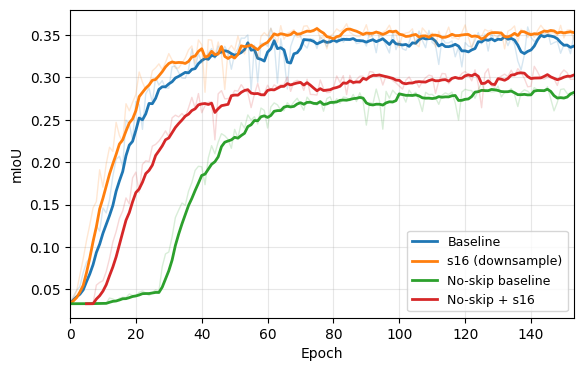

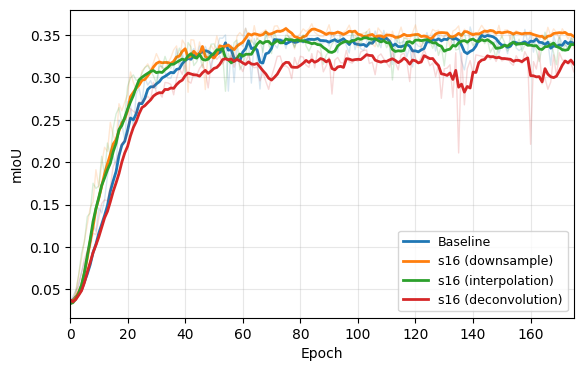

In [ ]:
# === Exporta as figuras do artigo (PDF vetorial) — self-contained ===
import matplotlib.pyplot as plt
import pandas as pd

SMOOTH = 5
exp = {
    "FCN8 Baseline":              "metrics_FCN8_1-exit.csv",
    "FCN8 Aux s16 λ=0.1":         "metrics_FCN8_2-exit_s-16-0.1.csv",
    "FCN8 Aux s32 λ=0.1":         "metrics_FCN8_2-exit_s-32-0.1.csv",
    "FCN8 No Skip Baseline":      "metrics_FCN8_no-skip_1-exit.csv",
    "FCN8 No Skip Aux s16 λ=0.1": "metrics_FCN8_no-skip_2-exit_s-16-0.1.csv",
    "FCN8 Interp s16 λ=0.1":      "metrics_FCN8_interpolate_2exit_s16-0.1.csv",
    "FCN8 Upscale Aux s16 λ=0.1": "metrics_FCN8_upscale_2exit_s16-0.1.csv",
}
labels = {
    "FCN8 Baseline":              "Baseline",
    "FCN8 Aux s16 λ=0.1":         "s16 (downsample)",
    "FCN8 Aux s32 λ=0.1":         "s32 (downsample)",
    "FCN8 No Skip Baseline":      "No-skip baseline",
    "FCN8 No Skip Aux s16 λ=0.1": "No-skip + s16",
    "FCN8 Interp s16 λ=0.1":      "s16 (interpolation)",
    "FCN8 Upscale Aux s16 λ=0.1": "s16 (deconvolution)",
}

def curves(ax, names, col):
    dfs = {}
    for n in names:
        d = pd.read_csv(exp[n]); d.columns = d.columns.str.strip(); dfs[n] = d
    emax = min(int(d["epoch"].max()) for d in dfs.values())   # epoca comum do grupo
    for n in names:
        d = dfs[n][dfs[n]["epoch"] <= emax]                   # corta todas no mesmo ponto
        y = d[col].rolling(SMOOTH, min_periods=1).mean()
        ln, = ax.plot(d["epoch"], y, lw=2, label=labels.get(n, n))
        ax.plot(d["epoch"], d[col], lw=1, alpha=0.18, color=ln.get_color())
    ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    ax.set_xlim(0, emax)

# Fig 2 — baseline vs s16 vs s32
fig, ax = plt.subplots(figsize=(6.5, 4))
curves(ax, ["FCN8 Baseline", "FCN8 Aux s16 λ=0.1", "FCN8 Aux s32 λ=0.1"], "miou")
ax.set_ylabel("mIoU"); fig.savefig("fig2_s16_vs_s32.pdf", bbox_inches="tight"); plt.show()

# Fig 3 — no-skip
fig, ax = plt.subplots(figsize=(6.5, 4))
curves(ax, ["FCN8 Baseline", "FCN8 Aux s16 λ=0.1",
            "FCN8 No Skip Baseline", "FCN8 No Skip Aux s16 λ=0.1"], "miou")
ax.set_ylabel("mIoU"); fig.savefig("fig3_noskip.pdf", bbox_inches="tight"); plt.show()

# Fig 4 — resolution 3-way (mIoU)
fig, ax = plt.subplots(figsize=(6.5, 4))
curves(ax, ["FCN8 Baseline", "FCN8 Aux s16 λ=0.1",
            "FCN8 Interp s16 λ=0.1", "FCN8 Upscale Aux s16 λ=0.1"], "miou")
ax.set_ylabel("mIoU")
fig.savefig("fig4_resolution.pdf", bbox_inches="tight"); plt.show()
